In [84]:
# Базовые библиотеки
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [54]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [55]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", save: bool = False) -> None:
    
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if save:
        plt.savefig('artifacts/figures/curves_best.png')
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [56]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  
])

train_full = torchvision.datasets.EMNIST(
    root="./data", split='balanced', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split='balanced', train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [57]:
# Размер батча
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print(f"y min: {y_batch.min()}, y max: {y_batch.max()}")

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64
y min: 0, y max: 46


In [58]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [60]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [61]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break
    return history

epoch 01/20 | train loss=1.2776, acc=0.6264 | val loss=0.8209, acc=0.7475
epoch 02/20 | train loss=0.7117, acc=0.7723 | val loss=0.6655, acc=0.7868
epoch 03/20 | train loss=0.5970, acc=0.8026 | val loss=0.6440, acc=0.7905
epoch 04/20 | train loss=0.5356, acc=0.8184 | val loss=0.5908, acc=0.8033
epoch 05/20 | train loss=0.4924, acc=0.8306 | val loss=0.5531, acc=0.8160
epoch 06/20 | train loss=0.4669, acc=0.8372 | val loss=0.5373, acc=0.8203
epoch 07/20 | train loss=0.4411, acc=0.8444 | val loss=0.5315, acc=0.8283
epoch 08/20 | train loss=0.4197, acc=0.8501 | val loss=0.5588, acc=0.8199
epoch 09/20 | train loss=0.4049, acc=0.8538 | val loss=0.5264, acc=0.8280
epoch 10/20 | train loss=0.3886, acc=0.8585 | val loss=0.5240, acc=0.8314
epoch 11/20 | train loss=0.3773, acc=0.8618 | val loss=0.5312, acc=0.8319
epoch 12/20 | train loss=0.3642, acc=0.8655 | val loss=0.5222, acc=0.8348
epoch 13/20 | train loss=0.3542, acc=0.8676 | val loss=0.5313, acc=0.8348
epoch 14/20 | train loss=0.3446, acc=0

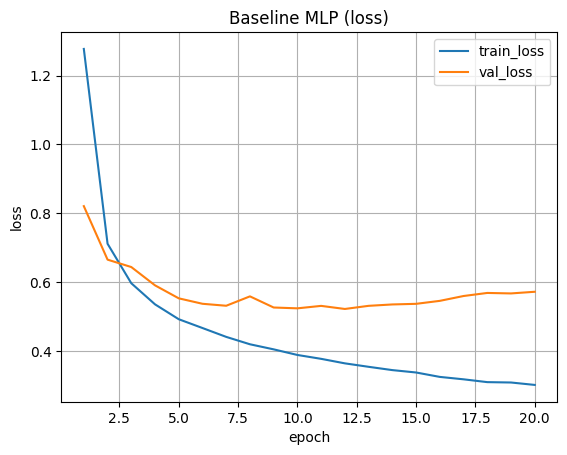

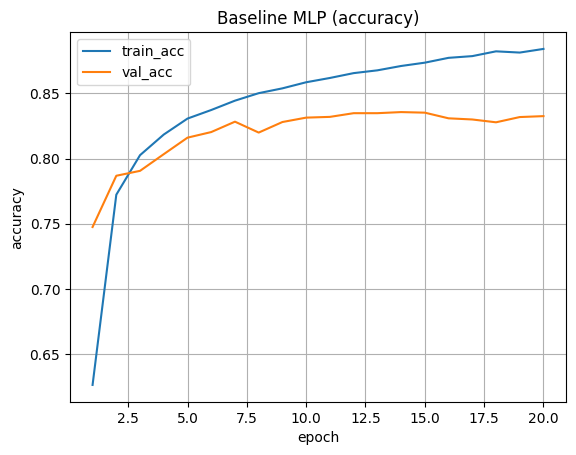

In [62]:
# E1: без Dropout и BatchNorm, 3 скрытых слоя
set_seed(42)
baseline = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=1.9229, acc=0.4431 | val loss=1.0214, acc=0.6892
epoch 02/20 | train loss=1.2980, acc=0.6073 | val loss=0.8403, acc=0.7367
epoch 03/20 | train loss=1.1732, acc=0.6426 | val loss=0.7794, acc=0.7581
epoch 04/20 | train loss=1.0953, acc=0.6638 | val loss=0.7423, acc=0.7597
epoch 05/20 | train loss=1.0564, acc=0.6743 | val loss=0.7142, acc=0.7727
epoch 06/20 | train loss=1.0294, acc=0.6820 | val loss=0.7138, acc=0.7718
epoch 07/20 | train loss=1.0040, acc=0.6893 | val loss=0.6739, acc=0.7789
epoch 08/20 | train loss=0.9884, acc=0.6923 | val loss=0.6852, acc=0.7734
epoch 09/20 | train loss=0.9664, acc=0.7006 | val loss=0.6517, acc=0.7867
epoch 10/20 | train loss=0.9551, acc=0.7012 | val loss=0.6539, acc=0.7818
epoch 11/20 | train loss=0.9491, acc=0.7053 | val loss=0.6368, acc=0.7863
epoch 12/20 | train loss=0.9349, acc=0.7069 | val loss=0.6358, acc=0.7924
epoch 13/20 | train loss=0.9301, acc=0.7092 | val loss=0.6323, acc=0.7897
epoch 14/20 | train loss=0.9146, acc=0

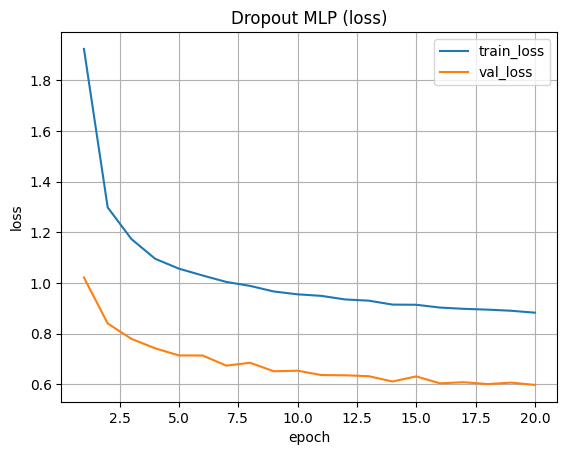

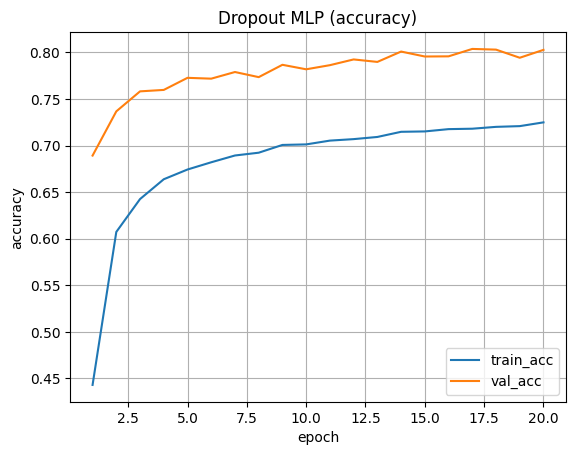

In [63]:
# E2: без BatchNorm, Dropout p = 0.3, 3 скрытых слоя
dropout_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout_model = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout_model, title="Dropout MLP")

epoch 01/20 | train loss=1.0009, acc=0.7237 | val loss=0.5920, acc=0.8041
epoch 02/20 | train loss=0.5537, acc=0.8157 | val loss=0.5050, acc=0.8315
epoch 03/20 | train loss=0.4794, acc=0.8346 | val loss=0.4716, acc=0.8412
epoch 04/20 | train loss=0.4364, acc=0.8484 | val loss=0.4659, acc=0.8405
epoch 05/20 | train loss=0.4042, acc=0.8554 | val loss=0.4547, acc=0.8462
epoch 06/20 | train loss=0.3800, acc=0.8632 | val loss=0.4461, acc=0.8498
epoch 07/20 | train loss=0.3608, acc=0.8674 | val loss=0.4487, acc=0.8473
epoch 08/20 | train loss=0.3433, acc=0.8725 | val loss=0.4395, acc=0.8521
epoch 09/20 | train loss=0.3281, acc=0.8767 | val loss=0.4421, acc=0.8541
epoch 10/20 | train loss=0.3169, acc=0.8811 | val loss=0.4419, acc=0.8538
epoch 11/20 | train loss=0.3033, acc=0.8844 | val loss=0.4509, acc=0.8500
epoch 12/20 | train loss=0.2920, acc=0.8880 | val loss=0.4518, acc=0.8522
epoch 13/20 | train loss=0.2832, acc=0.8911 | val loss=0.4545, acc=0.8540
epoch 14/20 | train loss=0.2735, acc=0

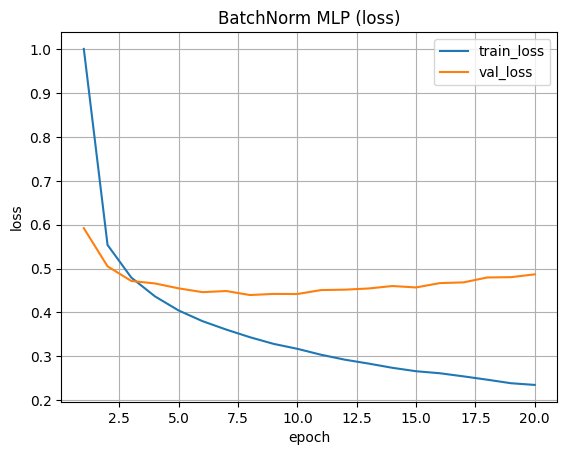

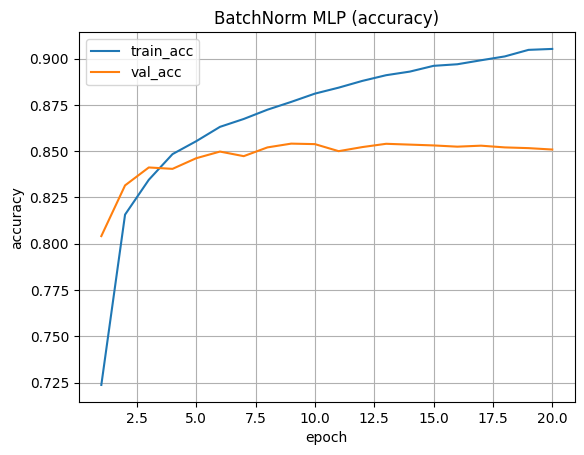

In [64]:
# E3: BatchNorm, без Dropout, 3 скрытых слоя
bn_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn_model = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn_model, title="BatchNorm MLP")

epoch 01/20 | train loss=1.0055, acc=0.7214 | val loss=0.5950, acc=0.8064
epoch 02/20 | train loss=0.5559, acc=0.8148 | val loss=0.4977, acc=0.8341
epoch 03/20 | train loss=0.4811, acc=0.8340 | val loss=0.4857, acc=0.8354
epoch 04/20 | train loss=0.4358, acc=0.8461 | val loss=0.4553, acc=0.8450
epoch 05/20 | train loss=0.4038, acc=0.8558 | val loss=0.4494, acc=0.8487
epoch 06/20 | train loss=0.3770, acc=0.8630 | val loss=0.4498, acc=0.8476
epoch 07/20 | train loss=0.3594, acc=0.8688 | val loss=0.4471, acc=0.8500
epoch 08/20 | train loss=0.3404, acc=0.8740 | val loss=0.4483, acc=0.8515
epoch 09/20 | train loss=0.3249, acc=0.8771 | val loss=0.4565, acc=0.8504
epoch 10/20 | train loss=0.3129, acc=0.8813 | val loss=0.4422, acc=0.8539
epoch 11/20 | train loss=0.2992, acc=0.8859 | val loss=0.4450, acc=0.8572
epoch 12/20 | train loss=0.2894, acc=0.8891 | val loss=0.4488, acc=0.8546
epoch 13/20 | train loss=0.2804, acc=0.8922 | val loss=0.4585, acc=0.8534
epoch 14/20 | train loss=0.2690, acc=0

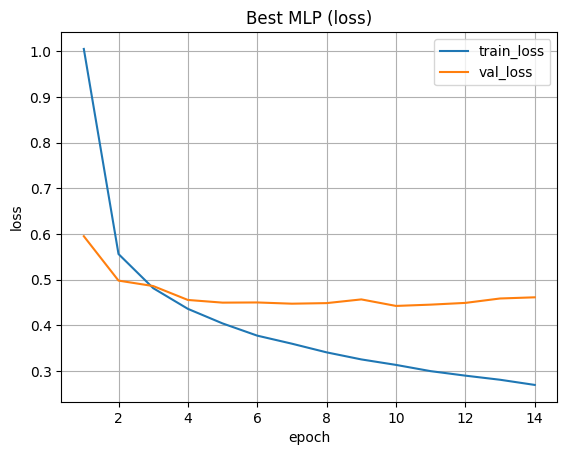

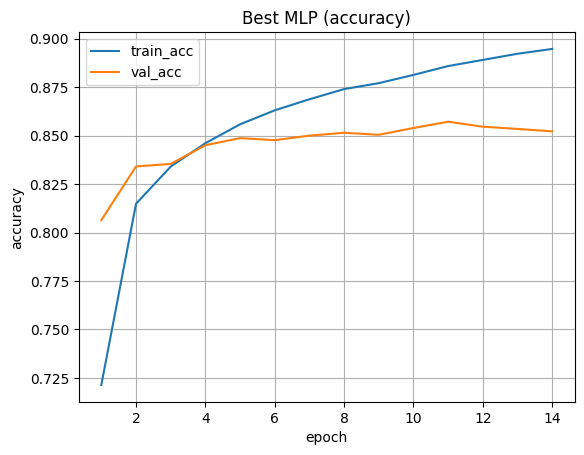

Best model test: loss=0.4741, acc=0.8519


In [65]:
# E4: E3 (как модель с лучшей val_acc) + EarlyStopping
best_model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=3, min_delta=0.0005)

history_best_model = fit(
    best_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=es
)

plot_history(history_best_model, title="Best MLP", save=True)
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Best model test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [66]:
# Сохраняем лучшую модель
torch.save(best_model.state_dict(), 'artifacts/best_model.pt')

# Словарь со всеми параметрами эксперимента
best_config = {
    "dataset": "EMNIST",
    "seed": 42,
    
    # Архитектура модели
    "model": {
        "input_dim": 784,
        "hidden_dims": [256, 128, 64],
        "num_classes": 47,
        "activation": "relu",
        "dropout_p": 0.0,
        "use_batchnorm": True
    },
    
    # Гиперпараметры обучения
    "training": {
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": 0,
        "weight_decay": 0,
        "batch_size": 64,
        "epochs": 20
    }
}

with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)

In [67]:
def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

def run_experiment(optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=8):
    model = MLP(hidden_dims=(256, 128, 64), dropout_p=0.0, use_batchnorm=True).to(device)
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, device=device, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

epoch 01/8 | train loss=1.5882, acc=0.5331 | val loss=1.0922, acc=0.6536
epoch 02/8 | train loss=1.0902, acc=0.6703 | val loss=0.9094, acc=0.7268
epoch 03/8 | train loss=0.9835, acc=0.7008 | val loss=0.8554, acc=0.7380
epoch 04/8 | train loss=0.9257, acc=0.7193 | val loss=0.8896, acc=0.7265
epoch 05/8 | train loss=0.8909, acc=0.7303 | val loss=0.7908, acc=0.7650
epoch 06/8 | train loss=0.8578, acc=0.7391 | val loss=0.7565, acc=0.7664
epoch 07/8 | train loss=0.8039, acc=0.7512 | val loss=0.8558, acc=0.7556
epoch 08/8 | train loss=0.8041, acc=0.7541 | val loss=0.7857, acc=0.7782


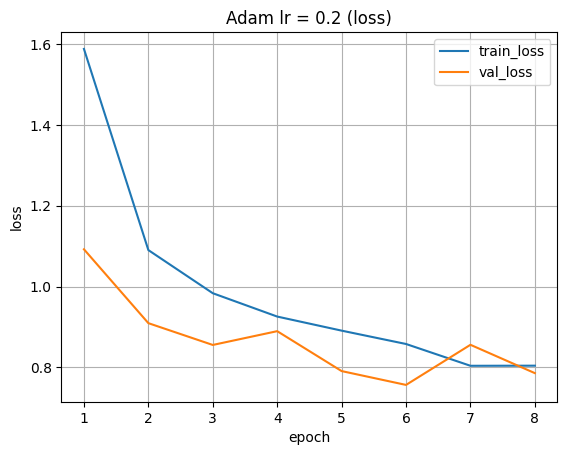

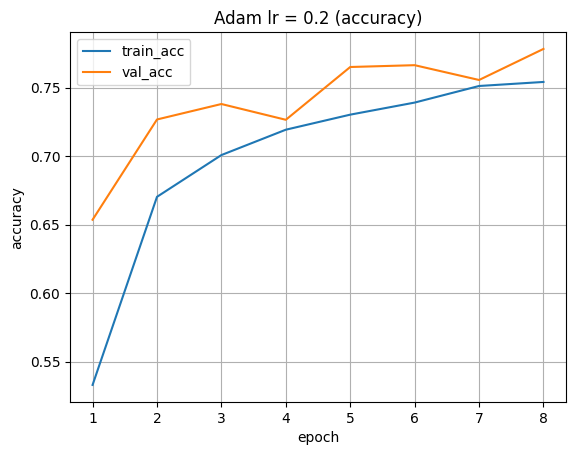

In [69]:
# O1: лучшая модель из Е4, но слишком большой шаг обучения
model_o1 = run_experiment(optimizer_kind='adam', lr=0.2)

plot_history(model_o1["history"], title=f"Adam lr = 0.2")

epoch 01/8 | train loss=3.8966, acc=0.0253 | val loss=3.8326, acc=0.0311
epoch 02/8 | train loss=3.7740, acc=0.0426 | val loss=3.7202, acc=0.0553
epoch 03/8 | train loss=3.6708, acc=0.0674 | val loss=3.6244, acc=0.0830
epoch 04/8 | train loss=3.5839, acc=0.0981 | val loss=3.5474, acc=0.1153
epoch 05/8 | train loss=3.5101, acc=0.1301 | val loss=3.4806, acc=0.1471
epoch 06/8 | train loss=3.4452, acc=0.1652 | val loss=3.4133, acc=0.1845
epoch 07/8 | train loss=3.3880, acc=0.1981 | val loss=3.3575, acc=0.2199
epoch 08/8 | train loss=3.3345, acc=0.2311 | val loss=3.3129, acc=0.2536


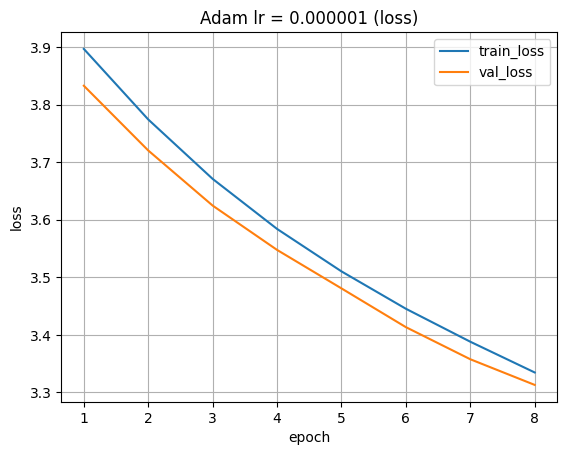

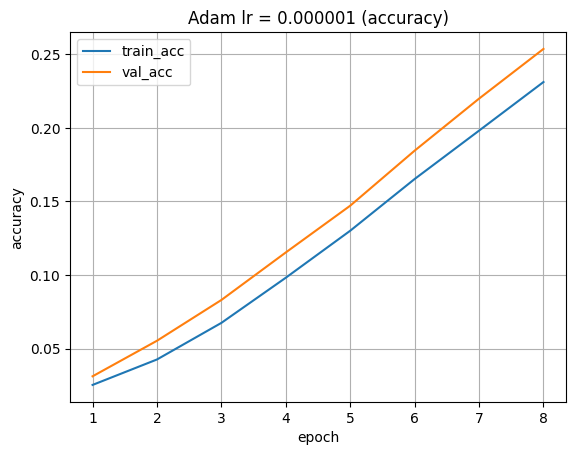

In [70]:
# O2: лучшая модель из Е4, но слишком маленький шаг обучения
model_o2 = run_experiment(optimizer_kind='adam', lr=0.000001)

plot_history(model_o2["history"], title=f"Adam lr = 0.000001")

In [78]:
history = model_o1['history']
print(history)

{'train_loss': [1.5881786102944233, 1.0902432861903035, 0.98349728470153, 0.9257152219613393, 0.8908662607695194, 0.8578149521815861, 0.8038744190271865, 0.8041446225228884], 'val_loss': [1.0922191401378967, 0.9093707913042128, 0.8554293646690866, 0.8895563407254962, 0.7907654821197304, 0.7565036230316918, 0.8558226351866304, 0.7856790982292327], 'train_acc': [0.5331117021276596, 0.6703346631205673, 0.7008089539007092, 0.7193040780141844, 0.7302859042553191, 0.739095744680851, 0.7511968085106383, 0.7541445035460993], 'val_acc': [0.6536384560906515, 0.7267616855524079, 0.7380488668555241, 0.7265403682719547, 0.7650495750708215, 0.7663774787535411, 0.7555771954674221, 0.7782400849858357]}


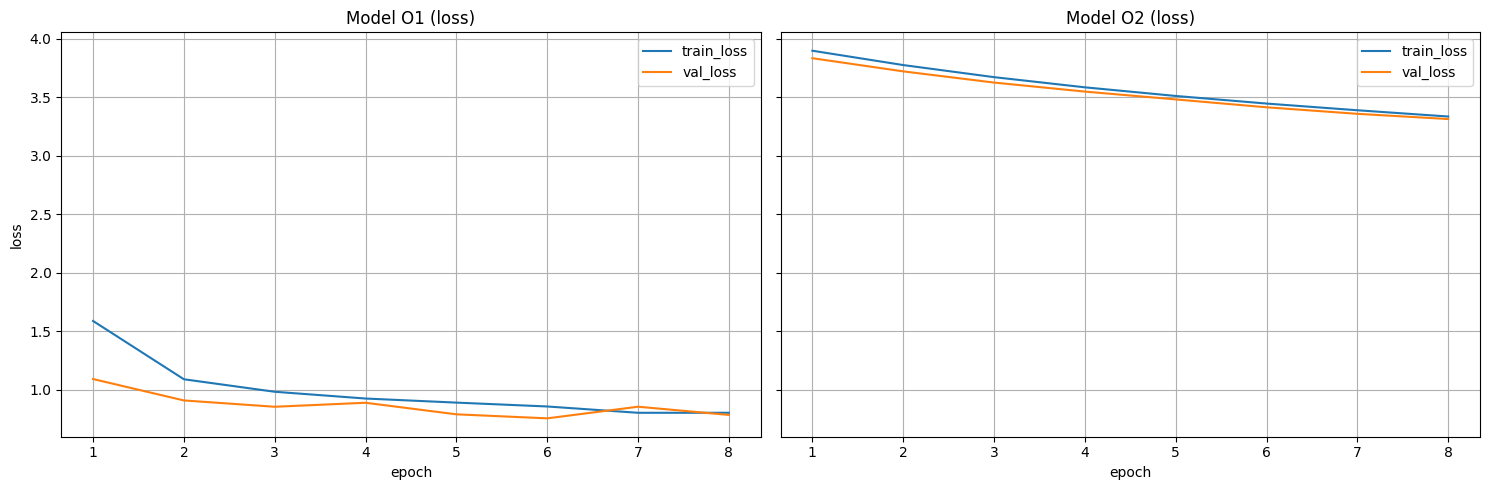

In [79]:
# График для сравнения О1 и О2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

history_o1 = model_o1["history"]
epochs_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
ax1.plot(epochs_o1, history_o1["train_loss"], label="train_loss")
ax1.plot(epochs_o1, history_o1["val_loss"], label="val_loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.set_title("Model O1 (loss)")
ax1.legend()
ax1.grid(True)

history_o2 = model_o2["history"]
epochs_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)
ax2.plot(epochs_o2, history_o2["train_loss"], label="train_loss")
ax2.plot(epochs_o2, history_o2["val_loss"], label="val_loss")
ax2.set_xlabel("epoch")
ax2.set_title("Model O2 (loss)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

epoch 01/15 | train loss=2.1663, acc=0.5395 | val loss=1.1876, acc=0.7197
epoch 02/15 | train loss=0.9771, acc=0.7450 | val loss=0.7685, acc=0.7843
epoch 03/15 | train loss=0.7189, acc=0.7896 | val loss=0.6368, acc=0.8079
epoch 04/15 | train loss=0.6096, acc=0.8142 | val loss=0.5740, acc=0.8199
epoch 05/15 | train loss=0.5422, acc=0.8278 | val loss=0.5406, acc=0.8266
epoch 06/15 | train loss=0.4999, acc=0.8386 | val loss=0.5243, acc=0.8279
epoch 07/15 | train loss=0.4665, acc=0.8473 | val loss=0.5103, acc=0.8329
epoch 08/15 | train loss=0.4411, acc=0.8529 | val loss=0.4887, acc=0.8376
epoch 09/15 | train loss=0.4199, acc=0.8579 | val loss=0.4852, acc=0.8400
epoch 10/15 | train loss=0.3995, acc=0.8640 | val loss=0.4803, acc=0.8403
epoch 11/15 | train loss=0.3855, acc=0.8671 | val loss=0.4654, acc=0.8453
epoch 12/15 | train loss=0.3676, acc=0.8724 | val loss=0.4646, acc=0.8456
epoch 13/15 | train loss=0.3556, acc=0.8751 | val loss=0.4662, acc=0.8439
epoch 14/15 | train loss=0.3440, acc=0

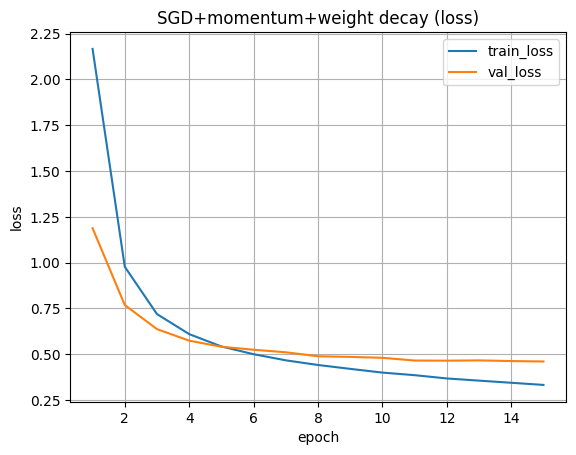

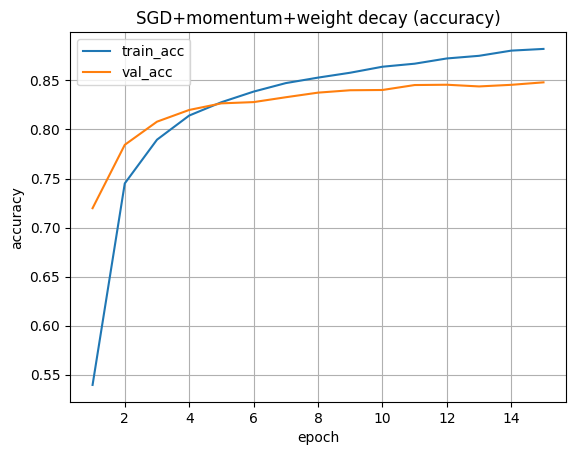

In [82]:
# O3: лучшая модель из Е4 и SGD+momentum+weight decay
model_o3 = run_experiment(optimizer_kind='sgd', lr=0.001, weight_decay=0.0001, momentum=0.9, epochs=15)

plot_history(model_o3["history"], title=f"SGD+momentum+weight decay")

In [86]:
d = {
    'experiment_id': ['E1', 'E2', 'E3', 'E4', 'O1', 'O2', 'O3'],
    'dataset': ['EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST'],
    'seed': [42, 42, 42, 42, 42, 42, 42],
    'model_summary': ['hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: False', 'hidden sizes: 3, activation: ReLU, dropout: 0.3, batchnorm: False', 'hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: True', 'hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: True', 'hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: True', 'hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: True', 'hidden sizes: 3, activation: ReLU, dropout: 0.0, batchnorm: True'],
    'optimizer': ['Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'SGD'],
    'lr': [1e-3, 1e-3, 1e-3, 1e-3, 0.2, 1e-6, 1e-3],
    'momentum': [0, 0, 0, 0, 0, 0, 0.9],
    'weight_decay': [0, 0, 0, 0, 0, 0, 1e-4], 
    'epochs_trained': [20, 20, 20, 14, 8, 8, 15],
    'best_val_accuracy': [0.5240, 0.5979, 0.4419, 0.4471, 0.7565, 3.3129, 0.4602],
    'best_val_loss': [0.8356, 0.8037, 0.8541, 0.8572, 0.7782, 0.2536, 0.8480]
}

runs = pd.DataFrame(d)
runs.to_csv('artifacts/runs.csv', index=False)
runs

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.001000,0.0,0.0000,20,0.5240,0.8356
1,E2,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.001000,0.0,0.0000,20,0.5979,0.8037
2,E3,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.001000,0.0,0.0000,20,0.4419,0.8541
3,E4,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.001000,0.0,0.0000,14,0.4471,0.8572
4,O1,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.200000,0.0,0.0000,8,0.7565,0.7782
5,O2,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",Adam,0.000001,0.0,0.0000,8,3.3129,0.2536
6,O3,EMNIST,42,"hidden sizes: 3, activation: ReLU, dropout: 0....",SGD,0.001000,0.9,0.0001,15,0.4602,0.8480
